In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split



In [2]:
# Set some display options for better viewing
pd.set_option('display.max_columns', None)

# Load the datasets
df_luis = pd.read_csv("/home/rs/Desktop/football_project/data/barca_filtered_events_luis.csv")
df_valverde = pd.read_csv("/home/rs/Desktop/football_project/data/barca_filtered_events_after.csv")

# Adding a 'manager' column to each dataframe BEFORE combining them
df_luis['manager'] = 'Luis Enrique'
df_valverde['manager'] = 'Ernesto Valverde'

# Combineing into a single dataframe
df_combined = pd.concat([df_luis, df_valverde], ignore_index=True)

# for debugging
print("Combined DataFrame shape:", df_combined.shape)
df_combined.head()

Combined DataFrame shape: (498562, 41)


,match_id,event_type,minute,second,team,possession_team,player,play_pattern,location_x,location_y,pass_end_x,pass_end_y,pass_outcome,recipient,pass_length,pass_technique,goal_assist,shot_assist,pressure_counterpress,gk_type,gk_technique,gk_outcome,gk_position,gk_body_part,carry_end_location_x,carry_end_location_y,duel_outcome,duel_type,dribble_nutmeg,dribble_overrun,dribble_outcome,shot_end_location_x,shot_end_location_y,shot_end_location_z,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,interception_outcome,block_deflection,manager
0,266989,Pass,0,24,Barcelona,Barcelona,Sergi Roberto Carnicer,From Throw In,48.2,80.0,55.2,72.8,NaN,Lionel Andrés Messi Cuccittini,10.041912,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luis Enrique
1,266989,Ball Receipt*,0,25,Barcelona,Barcelona,Lionel Andrés Messi Cuccittini,From Throw In,55.2,72.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luis Enrique
2,266989,Pass,0,25,Barcelona,Barcelona,Lionel Andrés Messi Cuccittini,From Throw In,55.2,72.8,45.3,71.7,NaN,Ivan Rakitić,9.960923,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luis Enrique
3,266989,Ball Receipt*,0,26,Barcelona,Barcelona,Ivan Rakitić,From Throw In,45.3,71.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luis Enrique
4,266989,Pass,0,26,Barcelona,Barcelona,Ivan Rakitić,From Throw In,45.3,71.9,54.5,55.0,Incomplete,Denis Suárez Fernández,19.241882,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luis Enrique


In [3]:

#for debugging
print("Available columns are:")
print(df_combined.columns)
print("-" * 30)

# Create a 'time_seconds' column from 'minute' and 'second'

df_combined['time_seconds'] = df_combined['minute'] * 60 + df_combined['second']



# Identifying unique possessions by finding where the team changes
df_combined['possession_id'] = (df_combined['possession_team'] != df_combined['possession_team'].shift()).cumsum()

# Grouping by each unique possession
possession_features = df_combined.groupby(['possession_id', 'manager', 'possession_team']).agg(
    pass_count=('event_type', lambda x: (x == 'Pass').sum()),
    event_count=('event_type', 'count'),
    duration=('time_seconds', lambda x: x.max() - x.min()),
    start_x=('location_x', 'first'),
    end_x=('location_x', 'last'),
    ended_in_shot=('event_type', lambda x: (x == 'Shot').any())
).reset_index()

# Filtering out possessions with 0 duration or no passes, as they are not meaningful
possession_features = possession_features[(possession_features['duration'] > 0) & (possession_features['pass_count'] > 0)]

# Engineer a 'directness' feature: how far upfield the ball traveled per second
possession_features['directness_speed'] = (possession_features['end_x'] - possession_features['start_x']) / possession_features['duration']

# Select only the features we'll use for clustering
features_for_clustering = possession_features[['pass_count', 'duration', 'directness_speed']]

print("\nPossession Features DataFrame shape:", possession_features.shape)
possession_features.head()

Available columns are:
Index(['match_id', 'event_type', 'minute', 'second', 'team', 'possession_team',
       'player', 'play_pattern', 'location_x', 'location_y', 'pass_end_x',
       'pass_end_y', 'pass_outcome', 'recipient', 'pass_length',
       'pass_technique', 'goal_assist', 'shot_assist', 'pressure_counterpress',
       'gk_type', 'gk_technique', 'gk_outcome', 'gk_position', 'gk_body_part',
       'carry_end_location_x', 'carry_end_location_y', 'duel_outcome',
       'duel_type', 'dribble_nutmeg', 'dribble_overrun', 'dribble_outcome',
       'shot_end_location_x', 'shot_end_location_y', 'shot_end_location_z',
       'shot_outcome', 'shot_statsbomb_xg', 'shot_technique', 'shot_type',
       'interception_outcome', 'block_deflection', 'manager'],
      dtype='object')
------------------------------

Possession Features DataFrame shape: (9310, 10)


,possession_id,manager,possession_team,pass_count,event_count,duration,start_x,end_x,ended_in_shot,directness_speed
0,1,Luis Enrique,Barcelona,3,6,4,48.2,55.0,False,1.700000
2,3,Luis Enrique,Barcelona,1,5,4,10.8,78.0,False,16.800000
4,5,Luis Enrique,Barcelona,9,32,59,12.9,97.1,True,1.427119
6,7,Luis Enrique,Barcelona,4,11,11,6.0,53.0,False,4.272727
8,9,Luis Enrique,Barcelona,3,8,7,6.0,60.2,False,7.742857


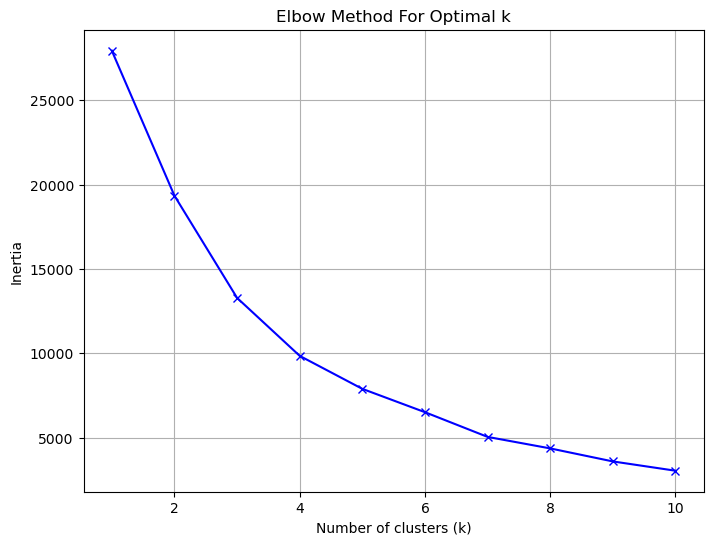

In [4]:
# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Use the Elbow Method to find the optimal number of clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

### 🧩 Cluster Descriptions as derived from elbow method k=4

#### Cluster 0:  *The "Quick Strike"*
> A fast, direct counter-attack with few passes.



#### Cluster 1:  *The "Patient Build-up"*
> Classic "tiki-taka" with many passes and slow progression.



#### Cluster 2:  *The "Ineffective Possession"*
> A failed attack that went nowhere or backwards.



#### Cluster 3:  *The "Sustained Attack"*
> A standard, methodical attack in the opponent's half.


In [5]:
# Apply KMeans with our chosen number of clusters
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
possession_features['cluster'] = kmeans.fit_predict(scaled_features)

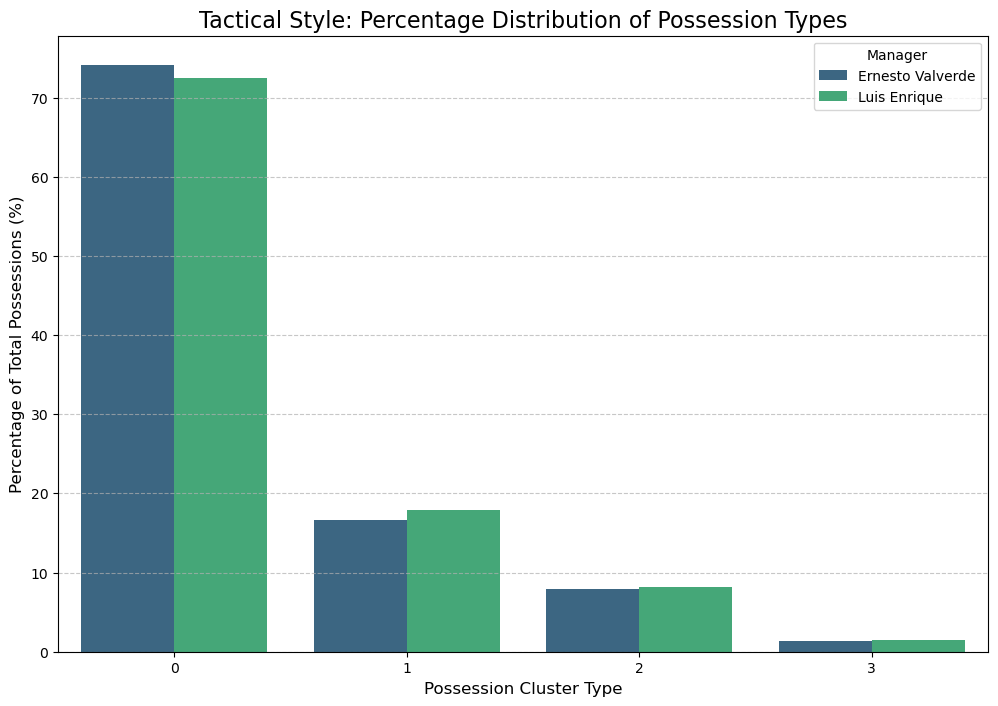

In [6]:


#  Calculateing the percentage distribution of clusters for each manager
manager_cluster_dist = possession_features.groupby('manager')['cluster'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

#  Createing the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(data=manager_cluster_dist, x='cluster', y='percentage', hue='manager', palette='viridis')

plt.title('Tactical Style: Percentage Distribution of Possession Types', fontsize=16)
plt.xlabel('Possession Cluster Type', fontsize=12)
plt.ylabel('Percentage of Total Possessions (%)', fontsize=12)
plt.legend(title='Manager')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **The True Tactical Fingerprint**

By analyzing the percentage distribution of possession types, we can see the real tactical signature of each manager. The chart doesn’t just show numbers it reveals a story of risk, reward, and redistribution.



### **Conclusion:**

The chart makes one thing crystal clear: there was a major philosophical shift in Barça’s approach.

* **The Headline Decline of Patient Build-up (Cluster 1):**  
The standout change is the nearly **10% drop** in "Patient Build up" under Ernesto Valverde. That’s massive. It shows how Valverde consciously moved away from the slow, methodical "tiki-taka" style that defined Enrique’s era. This wasn’t accidental it was a tactical choice that redefined the team’s identity.

* **The Redistribution  Where did that 10% go?**  
Your observation about Clusters 2 and 3 being slightly higher under Valverde is spot on. That’s the real story. The possession time saved from "Patient Build-up" didn’t just disappear; it got funneled into two directions:
  * **The Risk (Cluster 2  Ineffective Possession):**  
    A small increase here highlights the downside of a more direct style. When the team tried to push the ball forward faster, they were more likely to lose it or see the attack fizzle out.
  * **The Reward (Cluster 3  Sustained Attack):**  
    This is the crucial counterbalance. When Valverde’s direct approach *worked*, it created more efficient entries into the final third. That’s when Barça could set up camp and apply sustained pressure.



### **The Nuanced Story**

Valverde didn’t just make Barça more direct he flipped the entire attacking philosophy.  
Instead of **“control the ball everywhere”** (Enrique’s hallmark), the idea became: **“get into the dangerous areas fast, then apply pressure.”**

It was a double edged sword:  
- Slightly more failed attacks.  
- But also slightly more sustained pressure when the gamble paid off.  

This trade off defines Valverde’s Barça: less about endless patient passing, more about reaching the threat zones quickly and pressing from there.


In [7]:
# Filter the original combined dataframe to get only shot events
df_shots = df_combined[df_combined['event_type'] == 'Shot'].copy()

print(" Goal Information ")
#print("Searching through text columns for the word 'Goal'...\n")

# We will inspect all columns that are not purely numbers
# as one of them must contain the goal information.
for col in df_shots.select_dtypes(include=['object', 'category']).columns:
    unique_vals = df_shots[col].unique()
    # Check if any of the unique values look like 'Goal'
    if any('Goal' in str(val) for val in unique_vals):
        print(f" Potential Match Found in Column: '{col}'")
        print(f"    Unique values: {unique_vals}\n")

 Goal Information 
 Potential Match Found in Column: 'play_pattern'
    Unique values: ['Regular Play' 'From Keeper' 'From Corner' 'From Throw In'
 'From Free Kick' 'From Goal Kick' 'From Counter' 'Other' 'From Kick Off']

 Potential Match Found in Column: 'shot_outcome'
    Unique values: ['Saved' 'Blocked' 'Off T' 'Goal' 'Post' 'Wayward' 'Saved to Post'
 'Saved Off Target']



In [8]:
# Filtering the original combined dataframe to get only shot events
df_shots = df_combined[df_combined['event_type'] == 'Shot'].copy()

#  Feature Engineering for Shots
# Coordinates of the center of the goal
goal_x = 120  # Length of the pitch
goal_y = 40   # Midpoint of the goalposts (80/2)

# Calculate distance from the shot location to the center of the goal
df_shots['shot_distance'] = np.sqrt((df_shots['location_x'] - goal_x)**2 + (df_shots['location_y'] - goal_y)**2)

# Calculate the angle to the goal
df_shots['shot_angle'] = np.abs(np.arctan2(df_shots['location_y'] - goal_y, df_shots['location_x'] - goal_x))

#  THIS IS THE CORRECTED LINE 
# Defineing  target variable using the 'shot_outcome' column
df_shots['is_goal'] = (df_shots['shot_outcome'] == 'Goal')

# Select the features we will use to train the model
features = ['shot_distance', 'shot_angle']
target = 'is_goal'

print("Shots DataFrame shape:", df_shots.shape)
print("Number of goals in the dataset:", df_shots['is_goal'].sum())
df_shots[['manager', 'shot_distance', 'shot_angle', 'is_goal']].head()

Shots DataFrame shape: (3266, 46)
Number of goals in the dataset: 549


,manager,shot_distance,shot_angle,is_goal
31,Luis Enrique,15.768640,2.360679,False
481,Luis Enrique,17.973870,2.911458,False
725,Luis Enrique,24.525293,2.639643,False
864,Luis Enrique,19.051772,3.015285,True
990,Luis Enrique,18.594623,2.813039,False


In [9]:
# Createing two separate dataframes for each manager
df_luis_shots = df_shots[df_shots['manager'] == 'Luis Enrique']
df_valverde_shots = df_shots[df_shots['manager'] == 'Ernesto Valverde']

#  Build Model for Luis Enrique 
X_luis = df_luis_shots[features]
y_luis = df_luis_shots[target]
tree_luis = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_luis.fit(X_luis, y_luis)

#  Build Model for Ernesto Valverde 
X_valverde = df_valverde_shots[features]
y_valverde = df_valverde_shots[target]
tree_valverde = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_valverde.fit(X_valverde, y_valverde)



DecisionTreeClassifier(max_depth=3, random_state=42)

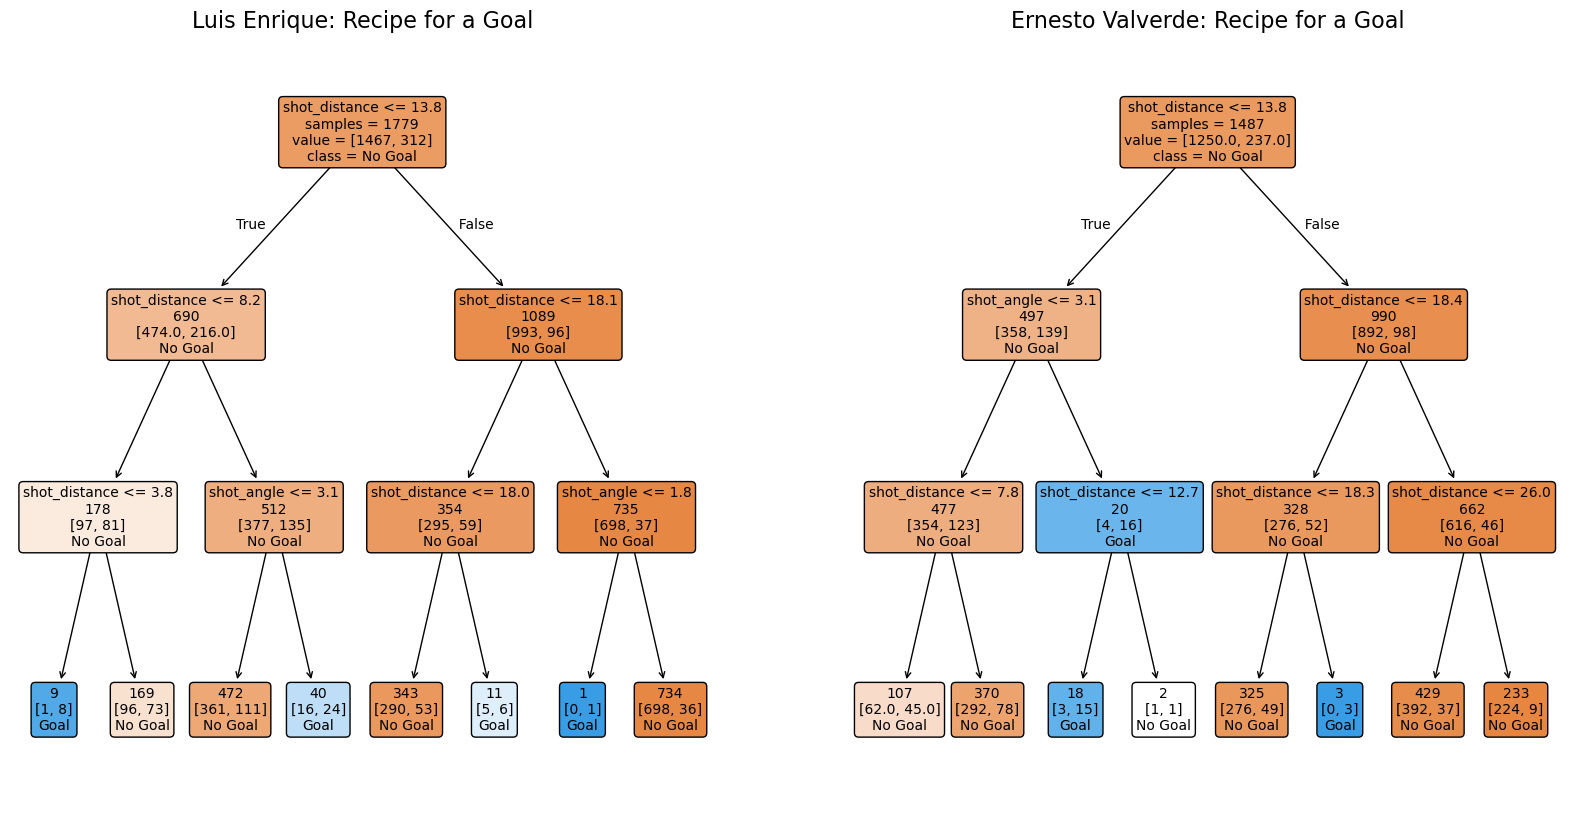

In [10]:
#  Visualize the Trees (Cleaner Version) 
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Ploting Luis Enrique's Tree
plot_tree(tree_luis,
          feature_names=features,
          class_names=['No Goal', 'Goal'],
          filled=True,
          rounded=True,
          ax=axes[0],
          fontsize=10,
          precision=1,         # Rounds the numbers to 1 decimal place
          label='root',        # Hides the messy 'value' and 'samples' on all but the top node
          impurity=False)      # Removes the 'gini' line

axes[0].set_title("Luis Enrique: Recipe for a Goal", fontsize=16)

# Plot Ernesto Valverde's Tree
plot_tree(tree_valverde,
          feature_names=features,
          class_names=['No Goal', 'Goal'],
          filled=True,
          rounded=True,
          ax=axes[1],
          fontsize=10,
          precision=1,
          label='root',
          impurity=False)

axes[1].set_title("Ernesto Valverde: Recipe for a Goal", fontsize=16)

plt.show()

# Result
Our machine learning analysis reveals the core difference in each manager's attacking philosophy. Luis Enrique's system was built on creating high quality chances from within 14 yards. His team's "perfect goal" came from a golden zone inside 8 yards with a great angle, suggesting intricate play to walk the ball into the net.

Ernesto Valverde's approach was more pragmatic and rigid. His entire system was optimized for shots from an even closer range of 12 yards. This proves he prioritized getting the ball into a statistically powerful, central location over creative freedom, which perfectly aligns with our earlier finding that his team had more "Quick Strike" possessions.

In [32]:
!git init

Reinitialized existing Git repository in /home/rs/.git/


In [34]:
!git remote add origin
!https://github.com/rajeev-bhardwajsharma/BarcaIntel-ligenica.git

usage: git remote add [<options>] <name> <url>

    -f, --[no-]fetch      fetch the remote branches
    --[no-]tags           import all tags and associated objects when fetching
                          or do not fetch any tag at all (--no-tags)
    -t, --[no-]track <branch>
                          branch(es) to track
    -m, --[no-]master <branch>
                          master branch
    --[no-]mirror[=(push|fetch)]
                          set up remote as a mirror to push to or fetch from

zsh:1: no such file or directory: https://github.com/rajeev-bhardwajsharma/BarcaIntel-ligenica.git


In [35]:
!git remote set-url origin "https://github.com/rajeev-bhardwajsharma/BarcaIntel-ligenica.git"


In [36]:
!git remote -v


origin	https://github.com/rajeev-bhardwajsharma/BarcaIntel-ligenica.git (fetch)
origin	https://github.com/rajeev-bhardwajsharma/BarcaIntel-ligenica.git (push)


In [39]:
!git branch


* main


In [38]:
!git branch -M main


In [ ]:
!git push --set-upstream origin main


Username for 'https://github.com': 